In [1]:
import os
from glob import glob
import pandas as pd
import numpy as np
import pickle
from spectral.io import envi
import matplotlib.pyplot as plt

%matplotlib widget

os.chdir('/store/carroll/col/data/2025/')

In [2]:
insitu = pd.read_csv('insitu/insitu_validation_target_mean.csv')
wvl_cols = [x for x in insitu.columns if x not in ['file_tag','date','site','utm_x','utm_y']]

wl_neon = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000 # nm
wl_asd = np.loadtxt('/store/carroll/col/data/wavelengths_asd.txt')[:,0]
wl_neon_nan = np.loadtxt('/store/carroll/col/data/wl_nan.txt')

def closest_wl(wl, mv):
    return np.nanargmin(np.abs(wl-mv))
wl_asd[closest_wl(wl_asd, 1360):closest_wl(wl_asd, 1410)] = np.nan
wl_asd[closest_wl(wl_asd, 1800):closest_wl(wl_asd, 1970)] = np.nan

fp = 'validation/single_val_pxs_bboxes.pkl'
with open(fp, 'rb') as f:
    bboxes = pickle.load(f)


In [3]:
fids = [x for x in glob('validation/*') if 'NIS01' in x]
fids = [x.split('/')[-1] for x in fids if 'carboncreek' not in x]
file_tags = list(set(['_'.join(x.split('_')[6:]) for x in fids]))

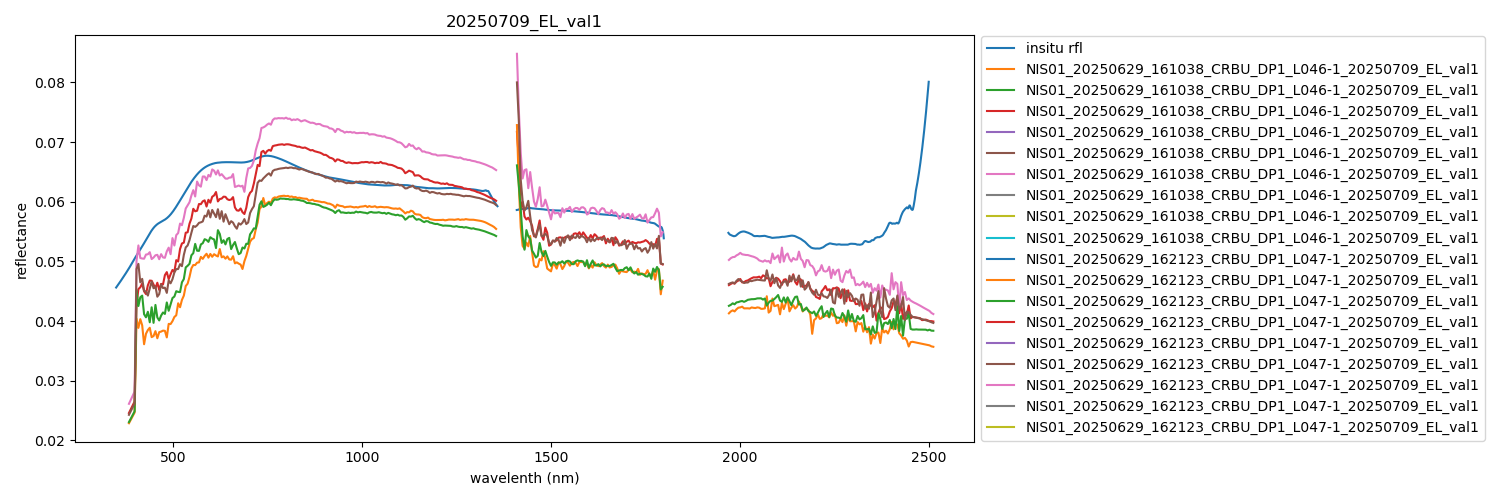

In [37]:
file_tag = '20250709_EL_val1'
site_fids = [x for x in fids if file_tag in x]
insitu_rfl = insitu.loc[insitu['file_tag']==file_tag, wvl_cols].values[0,:]

fig = plt.figure(figsize=(15,5))
plt.plot(wl_asd, insitu_rfl, label='insitu rfl')

for fid in site_fids:
    row1, row2, col1, col2 = bboxes[file_tag][fid]
    fid_mini = '_'.join(fid.split('_')[0:3])
    fp = glob(os.path.join('validation', fid, 'output', f'{fid_mini}_rfl.hdr'))[0]
    modeled_rfl = envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :].copy()# .reshape(-1,426).T
    ndvi = np.true_divide((modeled_rfl[...,89]-modeled_rfl[...,57]),(modeled_rfl[...,89]+modeled_rfl[...,57]))
    modeled_rfl[ndvi>0.1] = np.nan
    modeled_rfl = modeled_rfl.reshape(-1,426).T
    # modeled_rfl = np.nanmean(modeled_rfl, axis=(0,1))
    plt.plot(wl_neon_nan, modeled_rfl, label=fid)

plt.xlabel('wavelenth (nm)')
plt.ylabel('reflectance')
plt.title(file_tag)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

plt.show()

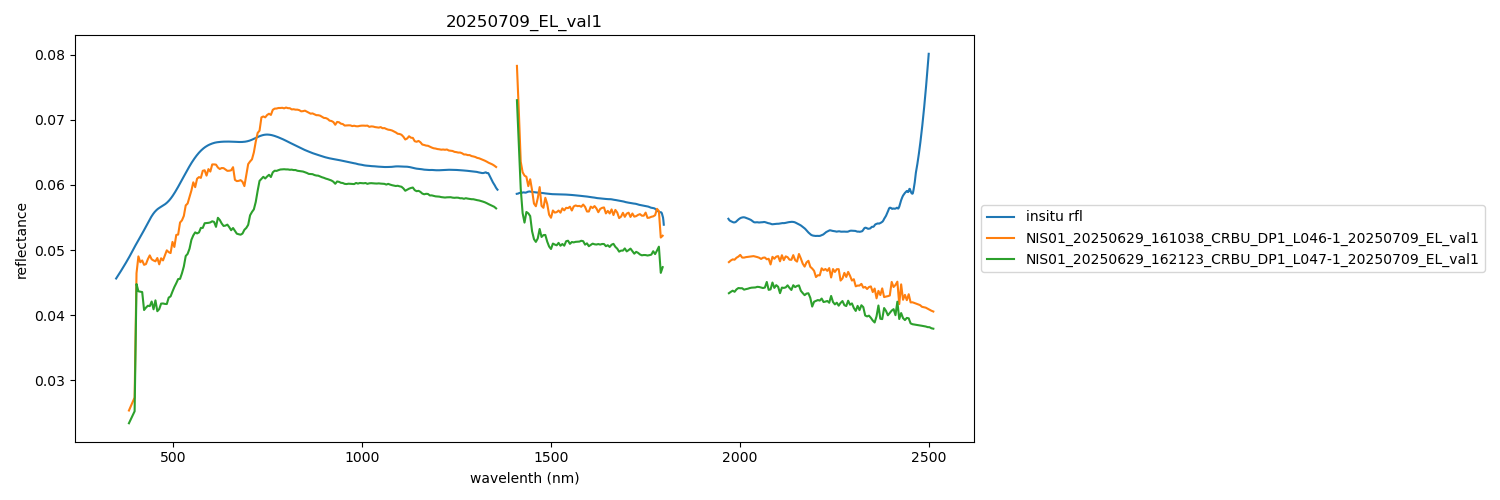

In [38]:
fig = plt.figure(figsize=(15,5))
plt.plot(wl_asd, insitu_rfl, label='insitu rfl')

for fid in site_fids:
    row1, row2, col1, col2 = bboxes[file_tag][fid]
    fid_mini = '_'.join(fid.split('_')[0:3])
    fp = glob(os.path.join('validation', fid, 'output', f'{fid_mini}_rfl.hdr'))[0]
    modeled_rfl = envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :].copy()# .reshape(-1,426).T
    ndvi = np.true_divide((modeled_rfl[...,89]-modeled_rfl[...,57]),(modeled_rfl[...,89]+modeled_rfl[...,57]))
    modeled_rfl[ndvi>0.1] = np.nan
    # modeled_rfl = modeled_rfl.reshape(-1,426).T
    modeled_rfl = np.nanmean(modeled_rfl, axis=(0,1))
    plt.plot(wl_neon_nan, modeled_rfl, label=fid)

plt.xlabel('wavelenth (nm)')
plt.ylabel('reflectance')
plt.title(file_tag)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

plt.show()

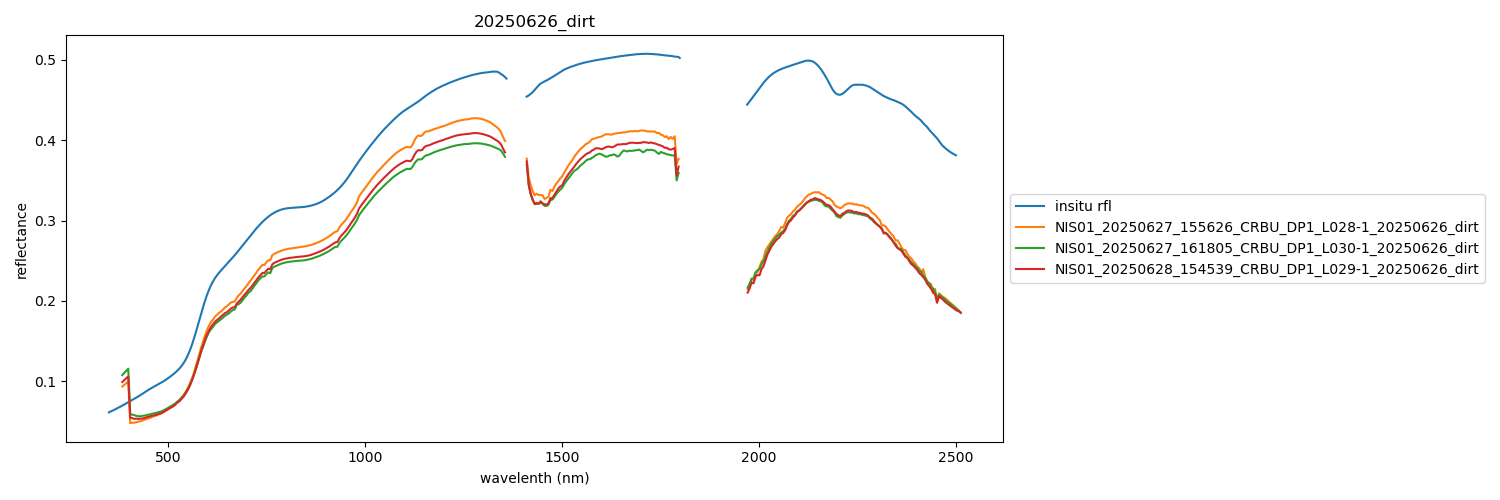

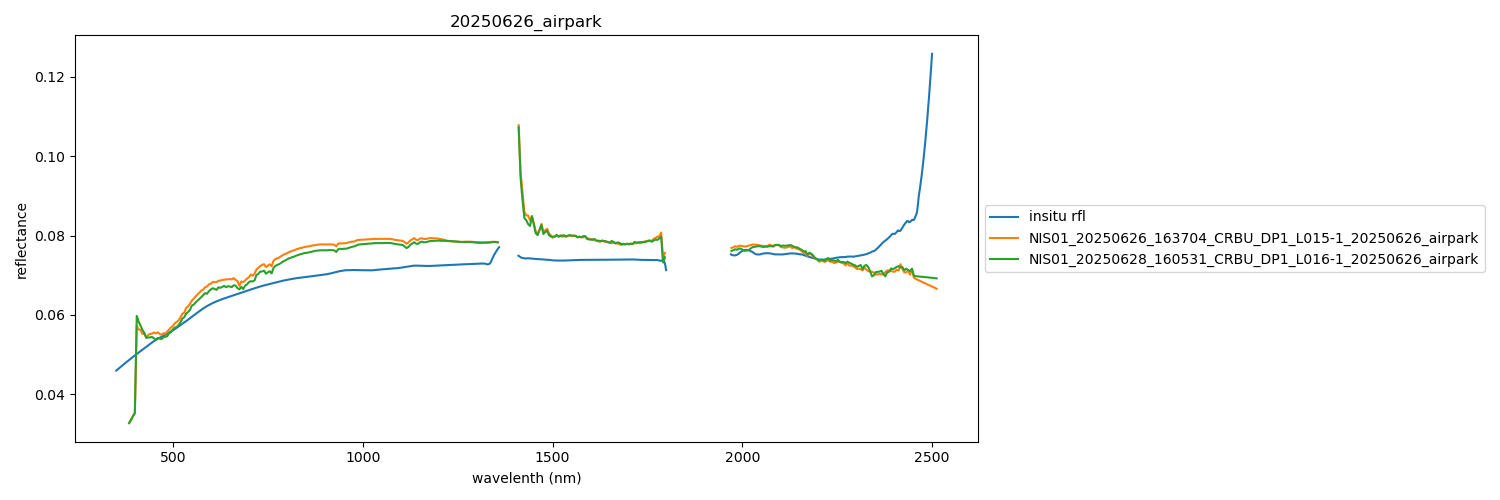

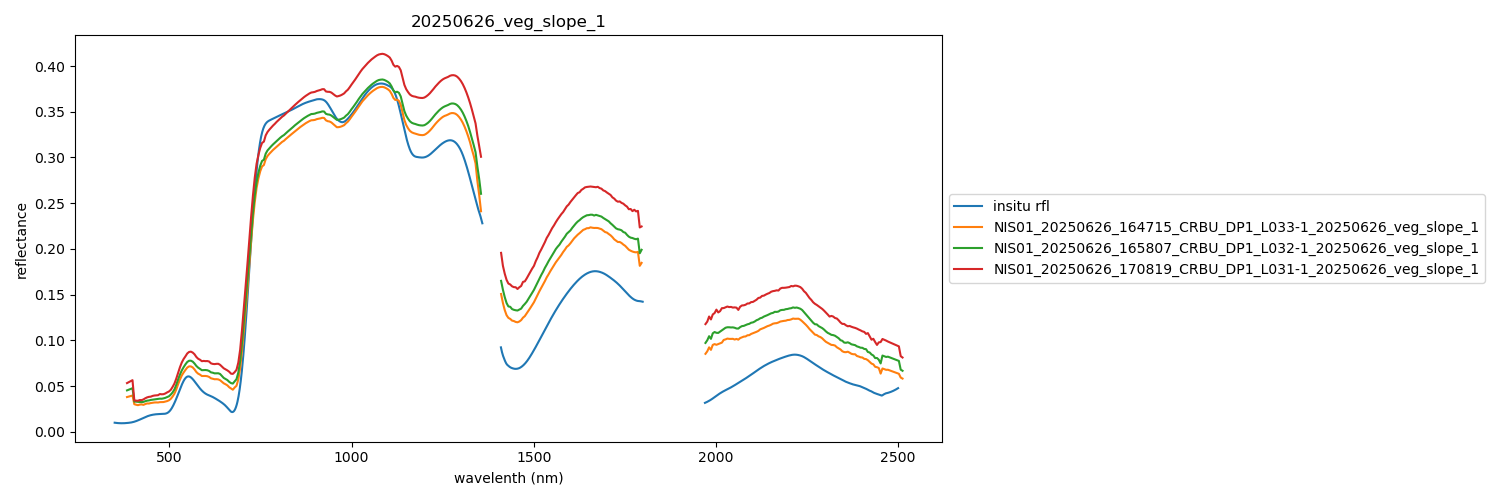

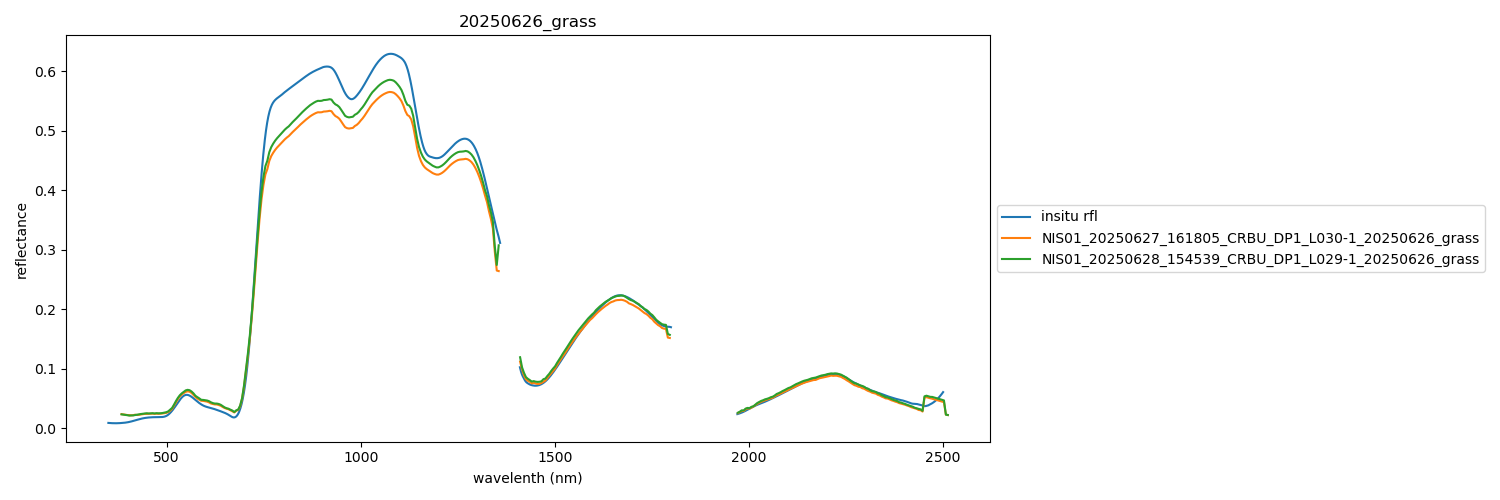

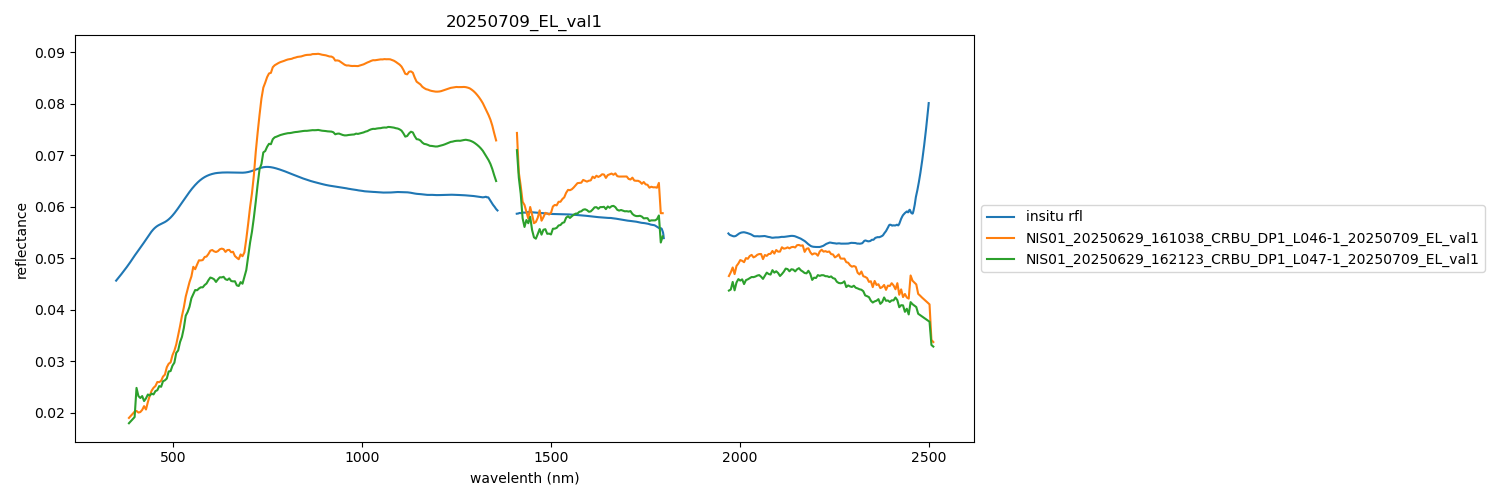

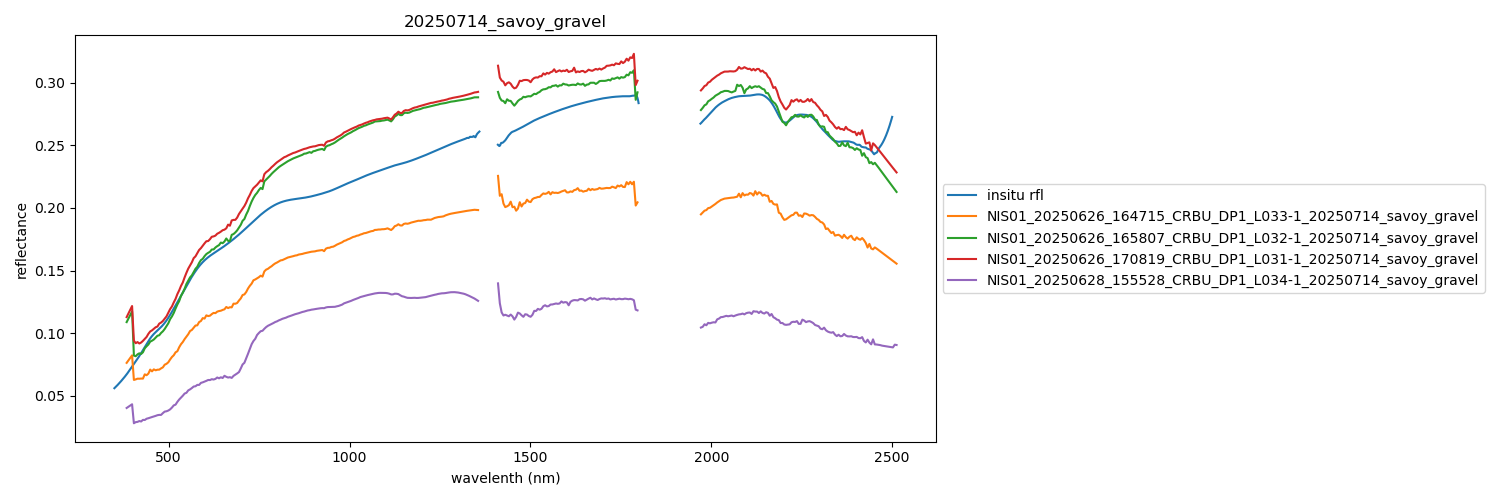

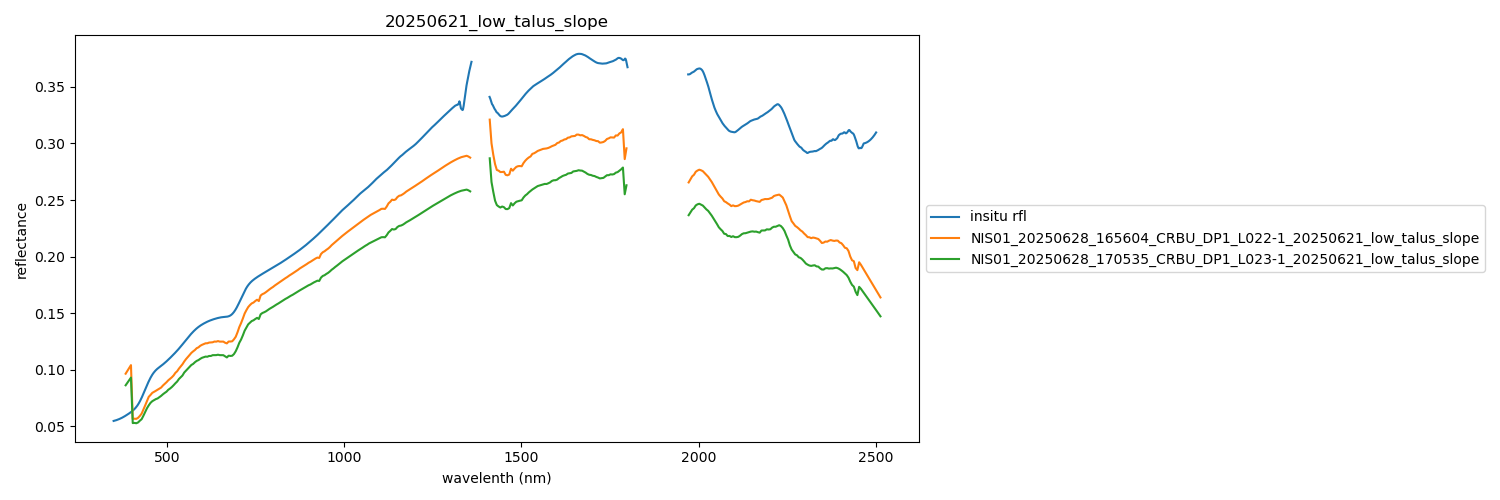

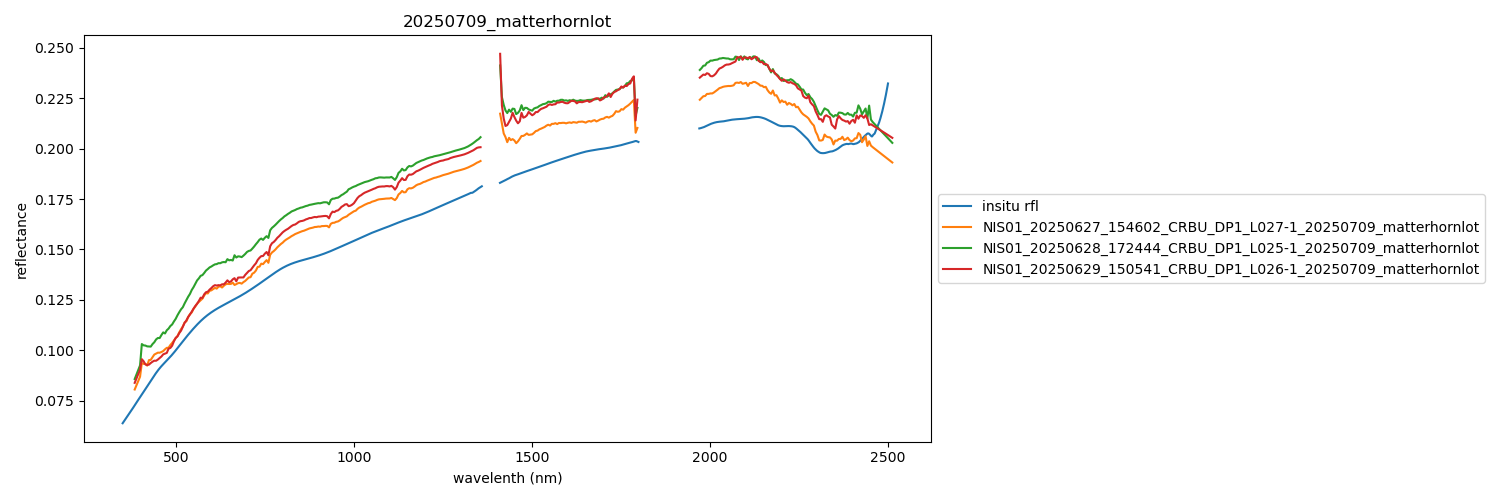

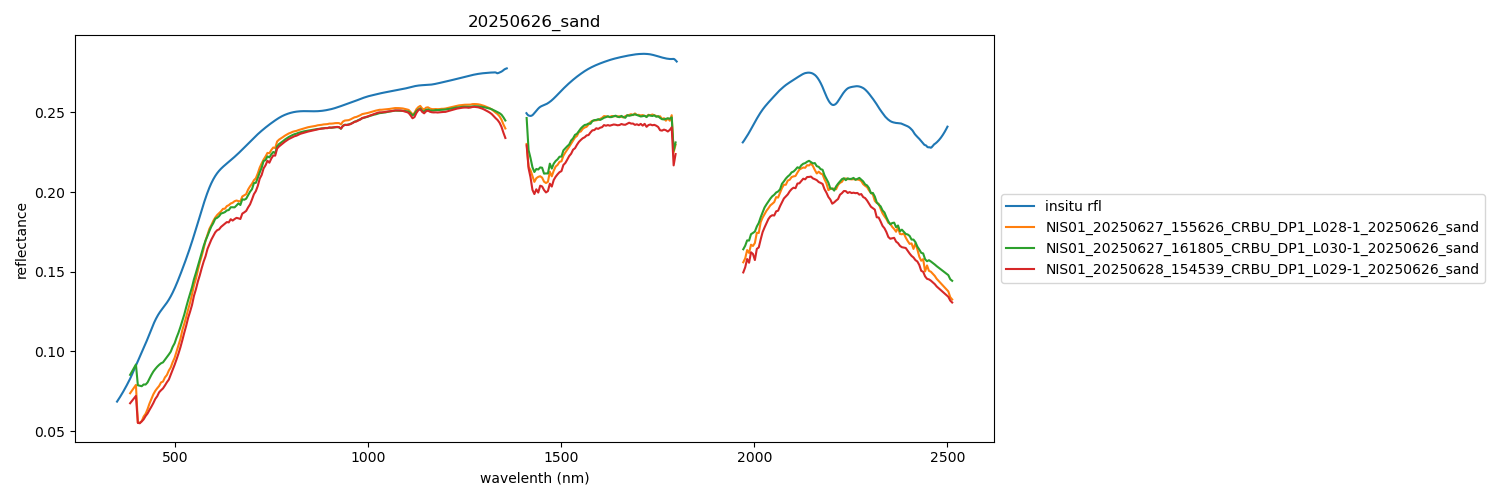

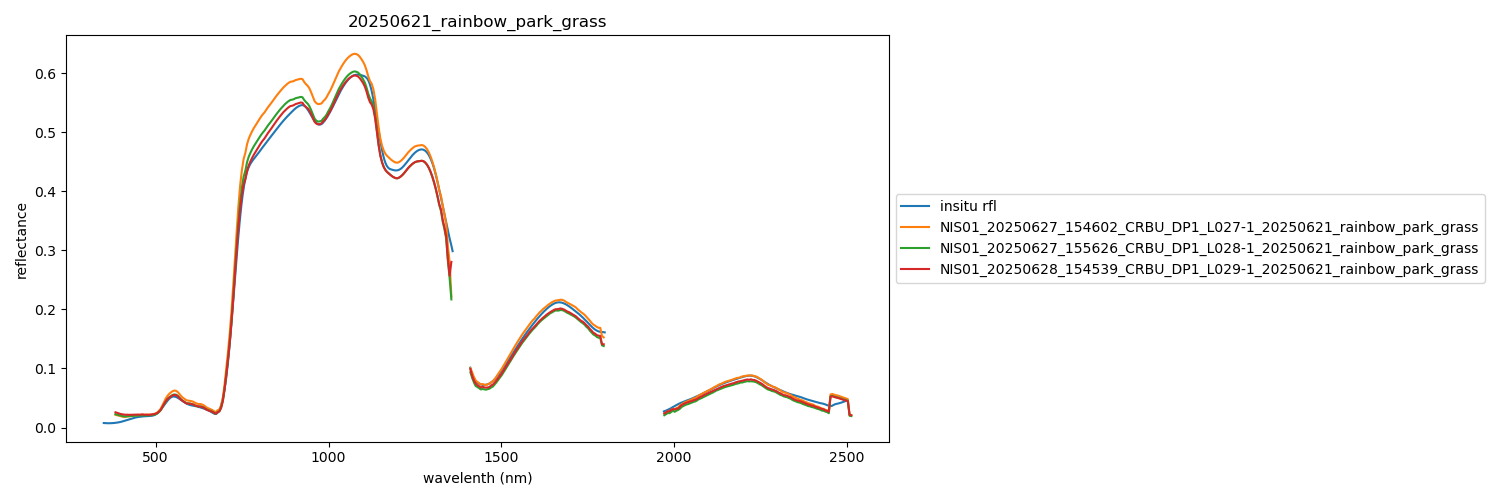

In [7]:
for file_tag in file_tags:
    site_fids = [x for x in fids if file_tag in x]
    insitu_rfl = insitu.loc[insitu['file_tag']==file_tag, wvl_cols].values[0,:]

    fig = plt.figure(figsize=(15,5))
    plt.plot(wl_asd, insitu_rfl, label='insitu rfl')
    
    for fid in site_fids:
        row1, row2, col1, col2 = bboxes[file_tag][fid]
        fid_mini = '_'.join(fid.split('_')[0:3])
        fp = glob(os.path.join('validation', fid, 'output', f'{fid_mini}_rfl.hdr'))[0]
        modeled_rfl = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))

        plt.plot(wl_neon_nan, modeled_rfl, label=fid)

    plt.xlabel('wavelenth (nm)')
    plt.ylabel('reflectance')
    plt.title(file_tag)
    # plt.legend()
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    fig.tight_layout()

#    plt.show()

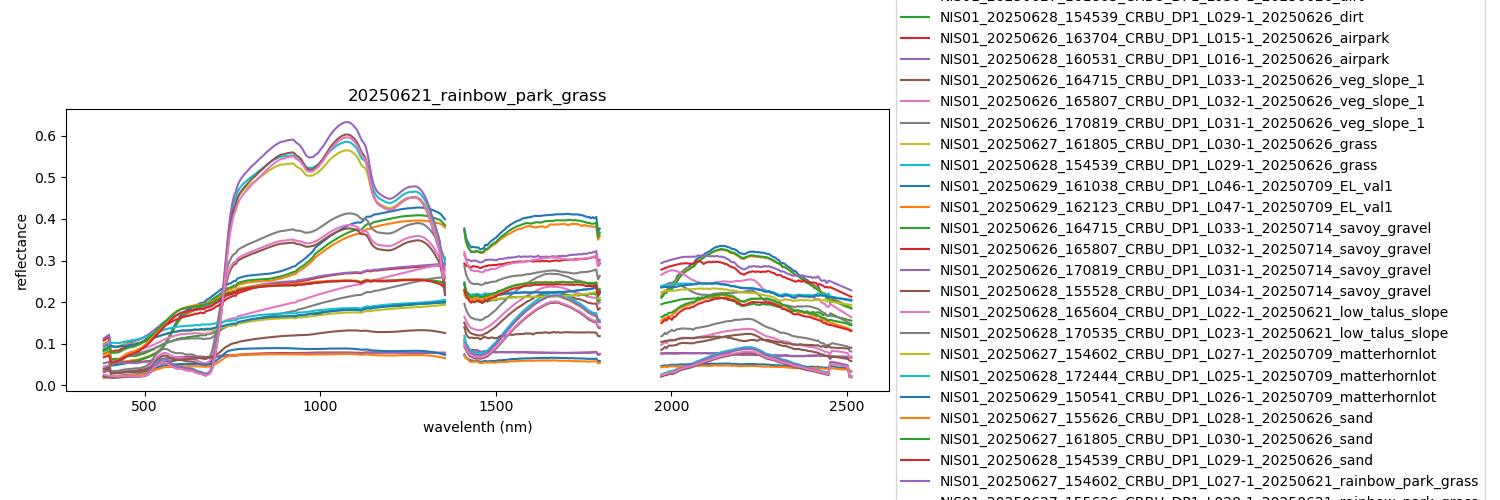

In [40]:
# look at all in situ rfl together

fig = plt.figure(figsize=(15,5))

for file_tag in file_tags:
    site_fids = [x for x in fids if file_tag in x]
    
    for fid in site_fids:
        row1, row2, col1, col2 = bboxes[file_tag][fid]
        fid_mini = '_'.join(fid.split('_')[0:3])
        fp = glob(os.path.join('validation', fid, 'output', f'{fid_mini}_rfl.hdr'))[0]
        modeled_rfl = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))

        plt.plot(wl_neon_nan, modeled_rfl, label=fid)

plt.xlabel('wavelenth (nm)')
plt.ylabel('reflectance')
plt.title(file_tag)
# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

plt.show()